<a href="https://colab.research.google.com/github/khanisaahmed/E-Commerce-Sales-Analysis-and-Prediction/blob/main/E-Commerce-Sales-Analysis-and-Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Data

In [ ]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("arhamrumi/amazon-product-reviews")

print("Path to dataset files:", path)

100%|██████████| 115M/115M [00:02<00:00, 40.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1


#Data Understanding

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

csv_file = os.path.join(path, "Reviews.csv")
df_raw = pd.read_csv(csv_file)

#Making a copy of the original dataset
df = df_raw.copy()

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())

print("\nNumeric Column Summary:\n", df.describe())

Dataset Shape: (568454, 10)

Column Names: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Data Types:
 Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

Missing Values:
 Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Numeric Column Summary:
                   Id  HelpfulnessNumerator  HelpfulnessDenominator  \
count  568454.000000         568454.000000         

In [ ]:
#Count of Unique Products with respect to number of reviews
df['ProductId'].nunique()

df['ProductId'].value_counts().head(10)

,count
ProductId,
B007JFMH8M,913
B002QWHJOU,632
B0026RQTGE,632
B002QWP89S,632
B002QWP8H0,632
B003B3OOPA,623
B001EO5Q64,567
B007M83302,564
B007M832YY,564



Score Distribution (%):
 Score
1     9.19
2     5.24
3     7.50
4    14.19
5    63.88
Name: count, dtype: float64


/tmp/ipykernel_6194/2986496519.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


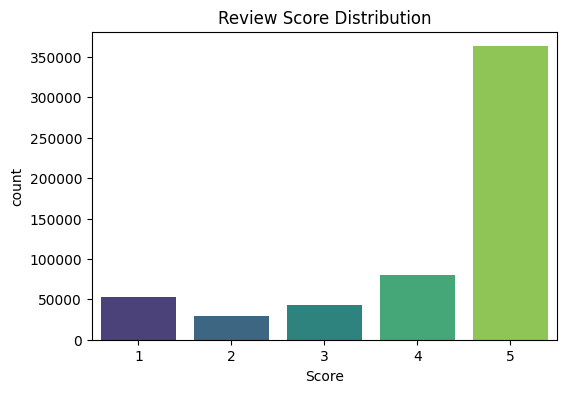


Date Range: 1999-10-08 00:00:00 to 2012-10-26 00:00:00


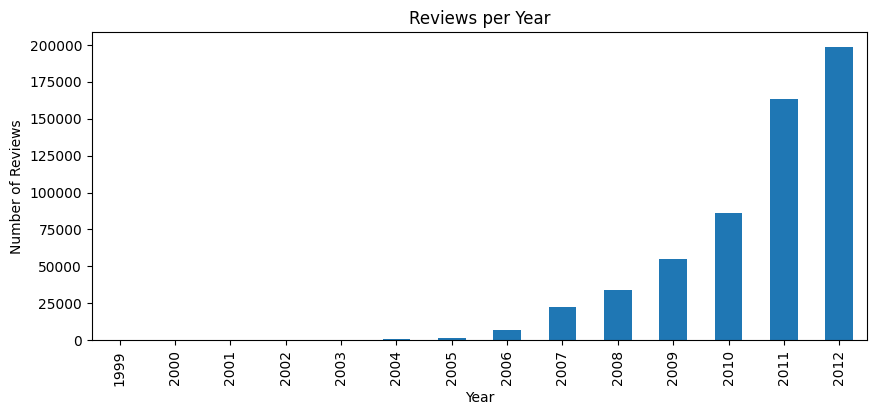

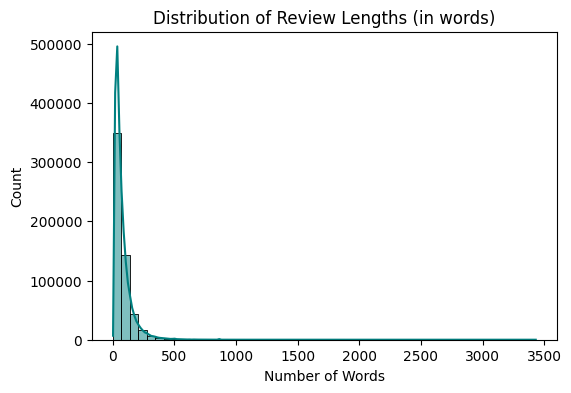

In [ ]:
score_counts = df['Score'].value_counts().sort_index()
score_percent = (score_counts / len(df) * 100).round(2)

print("\nScore Distribution (%):\n", score_percent)

plt.figure(figsize=(6,4))
sns.countplot(x='Score', data=df, palette='viridis')
plt.title("Review Score Distribution")
plt.show()

# Converting 'Time' column into readable datetime format
df['date'] = pd.to_datetime(df['Time'], unit='s', errors='coerce')
print("\nDate Range:", df['date'].min(), "to", df['date'].max())

plt.figure(figsize=(10,4))
df['date'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title("Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

# Creating a new column 'review_length' which stores word count of each review text
df['review_length'] = df['Text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(6,4))
sns.histplot(df['review_length'], bins=50, kde=True, color='teal')
plt.title("Distribution of Review Lengths (in words)")
plt.xlabel("Number of Words")
plt.show()

In [ ]:
df['help_ratio'] = df.apply(
    lambda r: r['HelpfulnessNumerator'] / r['HelpfulnessDenominator']
              if r['HelpfulnessDenominator'] > 0 else None,
    axis=1
)
print("\nHelpfulness Stats:")
print(df['help_ratio'].describe())


Helpfulness Stats:
count    298402.000000
mean          0.776975
std           0.346321
min           0.000000
25%           0.600000
50%           1.000000
75%           1.000000
max           3.000000
Name: help_ratio, dtype: float64


In [ ]:
# Counting duplicate reviews based on same ProductId, UserId, Time, and Text
dup_count = df.duplicated(subset=['ProductId','UserId','Time','Text']).sum()
print(f"\nNumber of duplicate reviews: {dup_count}")

df['year'] = df['date'].dt.year
reviews_per_year = df['year'].value_counts().sort_index()
print(reviews_per_year)


Number of duplicate reviews: 1205
year
1999         6
2000        32
2001        13
2002        73
2003       132
2004       561
2005      1335
2006      6671
2007     22300
2008     34163
2009     55326
2010     85884
2011    163299
2012    198659
Name: count, dtype: int64


In [ ]:
print("\n--- Quick Data Understanding Summary ---")
print(f"The dataset contains {df.shape[0]} reviews across {df['ProductId'].nunique()} products.")
print(f"Time span: {df['date'].min().date()} to {df['date'].max().date()}.")
print(f"Average review length: {df['review_length'].mean():.1f} words.")
print(f"Score distribution: {score_percent.to_dict()}")
print(f"About {df['help_ratio'].notna().mean()*100:.1f}% of reviews have helpfulness votes.")
print(f"There are {dup_count} duplicate reviews detected.")


--- Quick Data Understanding Summary ---
The dataset contains 568454 reviews across 74258 products.
Time span: 1999-10-08 to 2012-10-26.
Average review length: 80.3 words.
Score distribution: {1: 9.19, 2: 5.24, 3: 7.5, 4: 14.19, 5: 63.88}
About 52.5% of reviews have helpfulness votes.
There are 1205 duplicate reviews detected.


#Data Preprocessing

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=0f0317cb4c22c918b6aed2da1eec0f2c27fdfd393521c6fe5403b33eb4484ea4
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # to keep results consistent

In [ ]:
#Rmoving reviews that are in language other than english

def detect_language(text):
    try:# If the text is not a string or has less than 3 words,assume that it's English(eg: 'ok','yes')
        if not isinstance(text, str) or len(text.split()) < 3:
            return "en"  # assume very short reviews are English
        return detect(text)
    except:
        return "unknown"

df['language'] = df['Text'].apply(detect_language)

#Keep only English reviews
df = df[df['language'] == 'en'].copy()

df.drop(columns=['language'], inplace=True)

print("Filtered dataset size:", len(df))

Filtered dataset size: 568157


In [ ]:
print(f"Duplicate reviews detected: {dup_count}")

df = df.drop_duplicates(subset=['ProductId','UserId','Time','Text'], keep='first')

dup_count_after = df.duplicated(subset=['ProductId','UserId','Time','Text']).sum() #It keeps the first occurrence and drops the rest
print(f"Duplicate reviews after cleaning: {dup_count_after}")
print("New dataset shape:", df.shape)

Duplicate reviews detected: 1205
Duplicate reviews after cleaning: 0
New dataset shape: (566952, 14)


In [ ]:
df = df.dropna(subset=["help_ratio","ProfileName","Summary"])
print(df.isna().sum())

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
date                      0
review_length             0
help_ratio                0
year                      0
dtype: int64


In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove URLs
    text = re.sub(r'<.*?>', '', text)                   # remove HTML tags
    text = re.sub(r"[^a-z\s]", '', text)                 # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()             # remove extra spaces
    return text

df['clean_text'] = df['Text'].apply(clean_text)
print(df['Text'].head())

print("\nAfter Text Cleaning: ")
print(df['clean_text'].head())

0     I have bought several of the Vitality canned d...
2     This is a confection that has been around a fe...
3     If you are looking for the secret ingredient i...
8     Right now I'm mostly just sprouting this so my...
10    I don't know if it's the cactus or the tequila...
Name: Text, dtype: object

After Text Cleaning: 
0     i have bought several of the vitality canned d...
2     this is a confection that has been around a fe...
3     if you are looking for the secret ingredient i...
8     right now im mostly just sprouting this so my ...
10    i dont know if its the cactus or the tequila o...
Name: clean_text, dtype: object


year_group
1999-2006     7626
2007         17606
2008         23813
2009         37328
2010         54460
2011         88706
2012         67850
dtype: int64


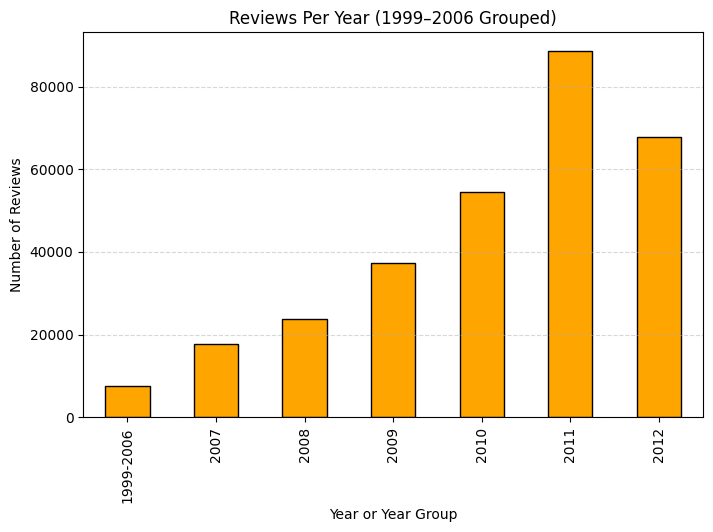

In [ ]:
df['year_group'] = df['year'].apply(lambda x: '1999-2006' if 1999<=x<=2006 else str(x))

# Counting how many reviews are in each year or year group
reviews_by_group = df.groupby('year_group').size()
print(reviews_by_group)

plt.figure(figsize=(8,5))
reviews_by_group.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Reviews Per Year (1999–2006 Grouped)")
plt.xlabel("Year or Year Group")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#Sentiment Analysis and Feature Engineering

In [ ]:
!pip install nltk

In [ ]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from google.colab import files

sia = SentimentIntensityAnalyzer()

# 'polarity_scores()' returns a dictionary with sentiment scores
sentiment = df['clean_text'].apply(lambda x: sia.polarity_scores(x))

# Extracting positive score for each review
df['sent_pos'] = sentiment.apply(lambda x: x['pos'])

# Extracting negative score for each review
df['sent_neg'] = sentiment.apply(lambda x: x['neg'])

# Extracting neutral score for each review
df['sent_neu'] = sentiment.apply(lambda x: x['neu'])

# Extracting compound score (overall sentiment score between -1 and +1)
df['sent_compound'] = sentiment.apply(lambda x: x['compound'])

df.to_csv("reviews_with_sentiment.csv", index=False)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
df[['Text','clean_text','sent_pos','sent_neg','sent_neu','sent_compound']].head()

,Text,clean_text,sent_pos,sent_neg,sent_neu,sent_compound
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,0.305,0.000,0.695,0.9441
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...,0.155,0.091,0.754,0.8265
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,0.075,0.000,0.925,0.4404
8,Right now I'm mostly just sprouting this so my...,right now im mostly just sprouting this so my ...,0.149,0.000,0.851,0.6369
10,I don't know if it's the cactus or the tequila...,i dont know if its the cactus or the tequila o...,0.137,0.018,0.845,0.9719


In [ ]:
# Creating new feature: review length in words
df['review_length_words'] = df['clean_text'].apply(lambda x: len(x.split()))

# Creating new feature: review length in characters
df['review_length_chars'] = df['clean_text'].apply(lambda x: len(x))

def sentiment_category(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment_category'] = df['sent_compound'].apply(sentiment_category)

df['date'] = pd.to_datetime(df['Time'], unit='s', errors='coerce')
first_date = df['date'].min()
df['review_age_days'] = (df['date'] - first_date).dt.days

# Creating a binary rating: 1 if Score ≥ 4 (positive review), else 0 (negative review)
df['rating_binary'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

df.to_csv("reviews_with_features.csv", index=False)

In [ ]:
df[['Score','sentiment_category','review_length_words','review_age_days']].head()

,Score,sentiment_category,review_length_words,review_age_days
0,5,Positive,48,4202
2,4,Positive,92,3220
3,2,Positive,41,4249
8,5,Positive,26,4412
10,5,Positive,140,1933


In [ ]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'date',
       'review_length', 'help_ratio', 'year', 'clean_text', 'year_group',
       'sent_pos', 'sent_neg', 'sent_neu', 'sent_compound',
       'review_length_words', 'review_length_chars', 'sentiment_category',
       'review_age_days', 'rating_binary'],
      dtype='object')


#Data Balancing

Ratings (1-5) distribution:
Score
5    175854
1     39697
4     38559
3     24164
2     19115
Name: count, dtype: int64
Score
5    59.13
1    13.35
4    12.97
3     8.13
2     6.43
Name: proportion, dtype: float64


/tmp/ipykernel_6194/396071751.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Score'], palette="Blues")


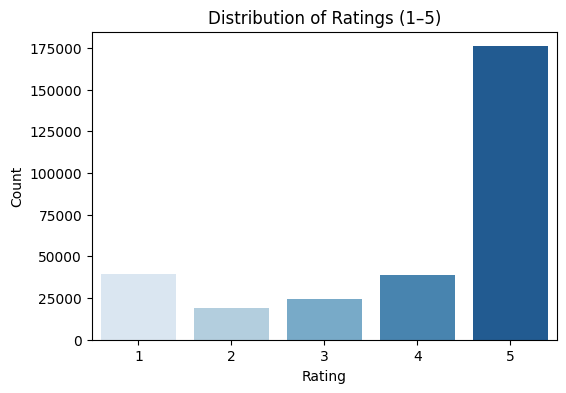

In [ ]:
!pip install imbalanced-learn

import pandas as pd
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

print("Ratings (1-5) distribution:")
print(df['Score'].value_counts())
print((df['Score'].value_counts(normalize=True)*100).round(2)) # normalize=True gives relative frequencies (proportions of total)

plt.figure(figsize=(6,4))
sns.countplot(x=df['Score'], palette="Blues")
plt.title("Distribution of Ratings (1–5)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Binary Rating Distribution:
rating_binary
1    214413
0     82976
Name: count, dtype: int64
rating_binary
1    72.1
0    27.9
Name: proportion, dtype: float64


/tmp/ipykernel_6194/2179578056.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['rating_binary'], palette="Greens")


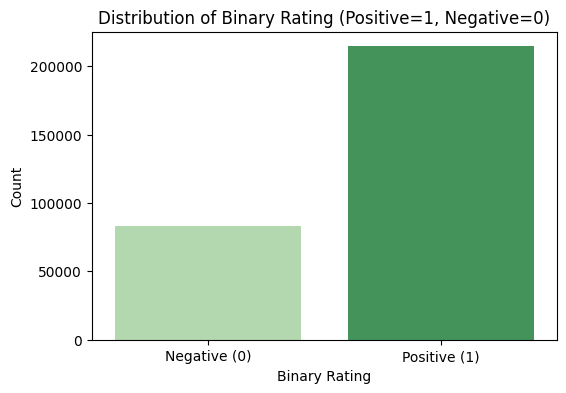

In [ ]:
df['rating_binary'] = (df['Score'] >= 4).astype(int)

# Printing binary rating distribution (counts of 0s and 1s)
print("Binary Rating Distribution:")
print(df['rating_binary'].value_counts())

# Printing binary rating distribution in percentages
print((df['rating_binary'].value_counts(normalize=True)*100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(x=df['rating_binary'], palette="Greens")
plt.title("Distribution of Binary Rating (Positive=1, Negative=0)")
plt.xlabel("Binary Rating")
plt.ylabel("Count")
plt.xticks([0,1], ["Negative (0)", "Positive (1)"])
plt.show()

In [ ]:
X = df.drop(columns=['Score', 'rating_binary'])
y = df['rating_binary']

ros = RandomOverSampler(random_state=42)

#creates a balanced dataset by oversampling the minority class
X_res, y_res = ros.fit_resample(X, y)

print("Before Balancing:", Counter(y))
print("After Balancing :", Counter(y_res))


# Combining balanced features (X_res) and target (y_res) into a new DataFrame
balanced_df = pd.concat([X_res, y_res], axis=1)
balanced_df.to_csv("Balanced_Reviews.csv", index=False)

Before Balancing: Counter({1: 214413, 0: 82976})
After Balancing : Counter({1: 214413, 0: 214413})


#EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

1. Correlation Heatmap

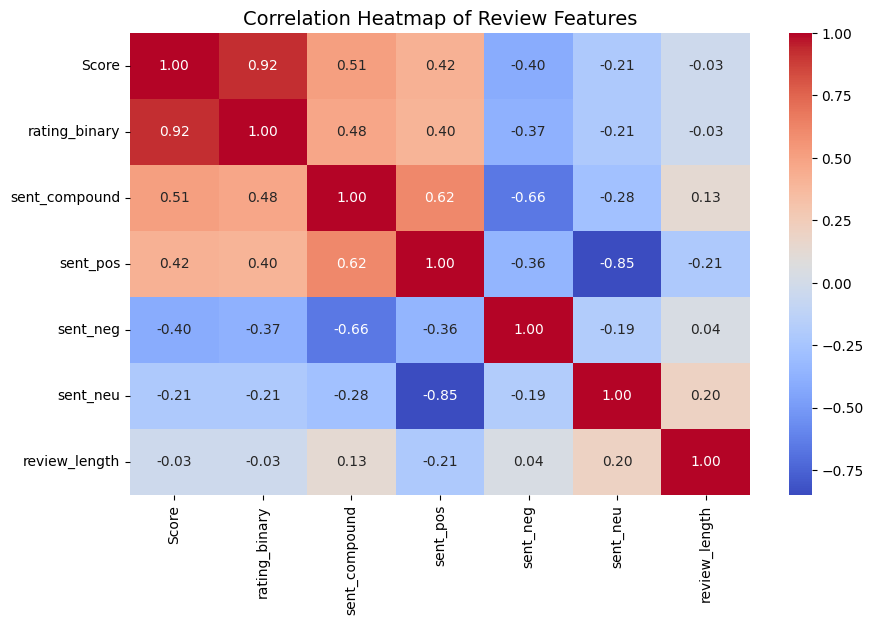

In [ ]:
# Select only the numeric features that we need
num_features = df[['Score', 'rating_binary',
                   'sent_compound', 'sent_pos', 'sent_neg', 'sent_neu', 'review_length']]

# Calculate correlation matrix
corr = num_features.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Review Features", fontsize=14)
plt.show()


2. Sentiment Score vs Ratings

       sent_compound  sent_pos  sent_neg  sent_neu
Score                                             
1           0.035839  0.098005  0.096757  0.805238
2           0.278629  0.117817  0.076892  0.805293
3           0.453057  0.136932  0.059603  0.803456
4           0.686700  0.180546  0.042132  0.777295
5           0.761665  0.211158  0.034228  0.754537


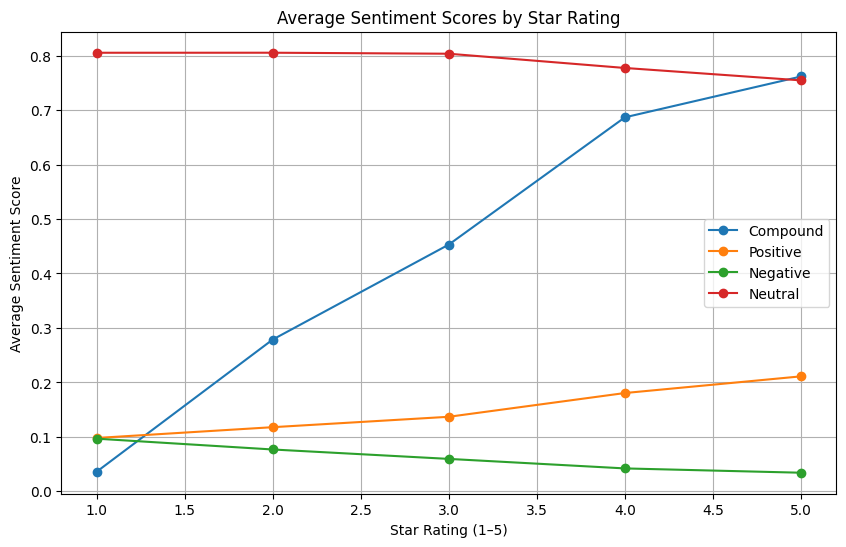

In [ ]:
# Group by Score (1–5 stars) and take mean of sentiment features
sentiment_by_rating = df.groupby('Score')[['sent_compound', 'sent_pos', 'sent_neg', 'sent_neu']].mean()

print(sentiment_by_rating)

plt.figure(figsize=(10,6))

plt.plot(sentiment_by_rating.index, sentiment_by_rating['sent_compound'], marker='o', label='Compound')
plt.plot(sentiment_by_rating.index, sentiment_by_rating['sent_pos'], marker='o', label='Positive')
plt.plot(sentiment_by_rating.index, sentiment_by_rating['sent_neg'], marker='o', label='Negative')
plt.plot(sentiment_by_rating.index, sentiment_by_rating['sent_neu'], marker='o', label='Neutral')

plt.title("Average Sentiment Scores by Star Rating")
plt.xlabel("Star Rating (1–5)")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.grid(True)
plt.show()

3. Number of reviews over time (all products combined)

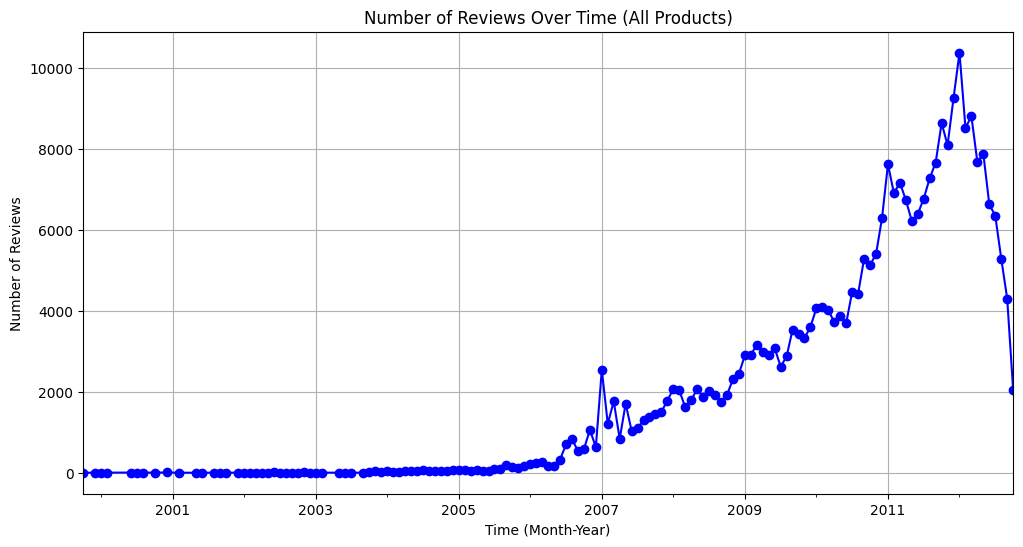

In [ ]:
df['YearMonth'] = df['date'].dt.to_period('M')

# Count reviews per month (for all products combined)
reviews_per_month = df.groupby('YearMonth').size()

# Plot overall review activity
plt.figure(figsize=(12,6))
reviews_per_month.plot(kind='line', marker='o', color='blue')
plt.title("Number of Reviews Over Time (All Products)")
plt.xlabel("Time (Month-Year)")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

4. Sentiment Trend Visualization(all products combined)

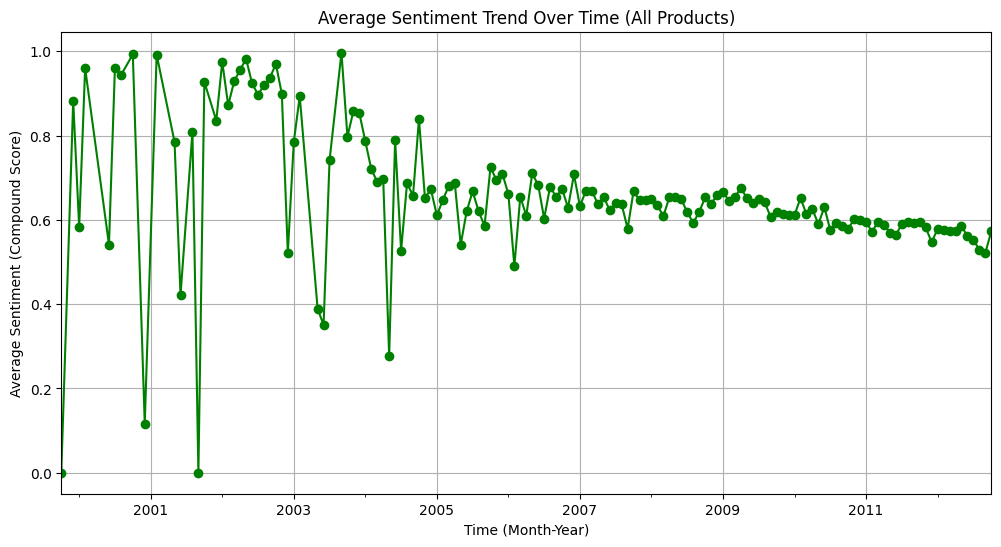

In [ ]:
# Average sentiment compound per month (all products combined)
sentiment_trend = df.groupby('YearMonth')['sent_compound'].mean()

# Plot
plt.figure(figsize=(12,6))
sentiment_trend.plot(kind='line', marker='o', color='green')
plt.title("Average Sentiment Trend Over Time (All Products)")
plt.xlabel("Time (Month-Year)")
plt.ylabel("Average Sentiment (Compound Score)")
plt.grid(True)
plt.show()

5. Sentiment Trend Visualization for a Particular Product

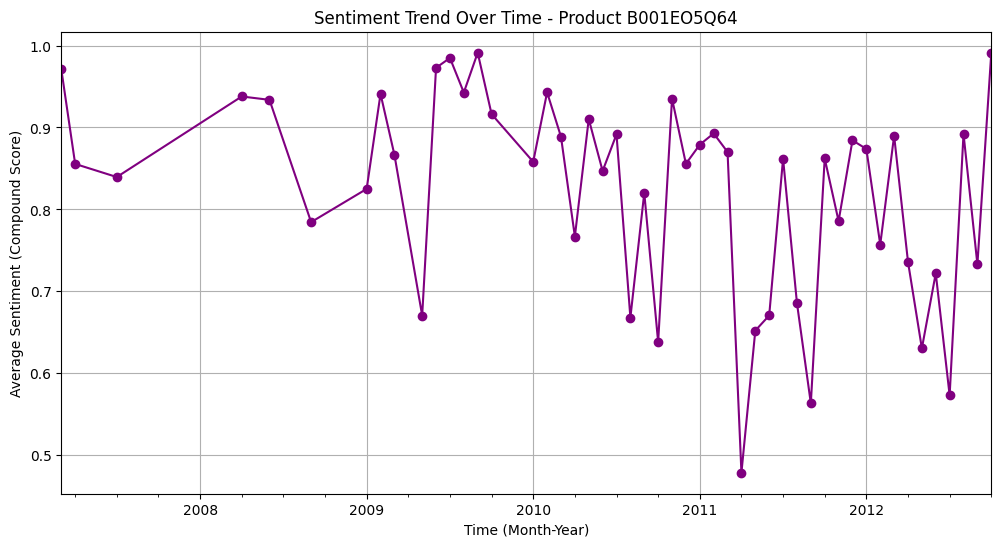

In [ ]:
# Choose a product
product_id = "B001EO5Q64"  # replace with an actual ProductId
product_reviews = df[df['ProductId'] == product_id]

# Average sentiment per month for that product
product_sentiment_trend = product_reviews.groupby('YearMonth')['sent_compound'].mean()

# Plot
plt.figure(figsize=(12,6))
product_sentiment_trend.plot(kind='line', marker='o', color='purple')
plt.title(f"Sentiment Trend Over Time - Product {product_id}")
plt.xlabel("Time (Month-Year)")
plt.ylabel("Average Sentiment (Compound Score)")
plt.grid(True)
plt.show()

# Model Training & Evaluation

1. Implementing LogisticRegression with no class weights

Logistic Regression Baseline Results
Accuracy: 0.7856182117757826
Precision: 0.8063689604685212
Recall: 0.9247020964018375
F1 Score: 0.8614910003367405

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.43      0.53     16595
           1       0.81      0.92      0.86     42883

    accuracy                           0.79     59478
   macro avg       0.75      0.68      0.69     59478
weighted avg       0.77      0.79      0.77     59478



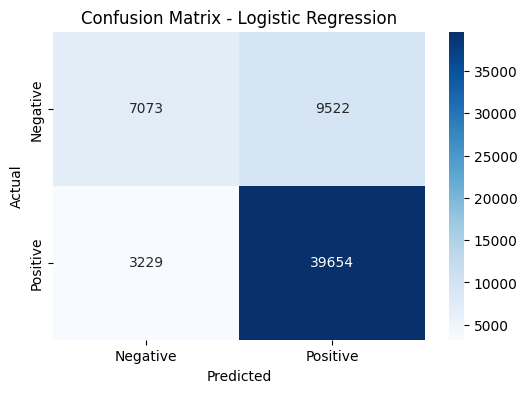

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select Features (X) and Target (y)
features = ['sent_compound', 'sent_pos', 'sent_neg', 'sent_neu', 'review_length']
X = df[features]
y = df['rating_binary']

# 2. Train-Test Split
# Splitting dataset into 80% training and 20% testing
# stratify=y ensures class balance is maintained in train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)  # max_iter = maximum number of iterations allowed for the solver to run
log_reg.fit(X_train, y_train)

# 4. Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]  # predicted probability for class 1

# 5. Evaluation
print("Logistic Regression Baseline Results")
print("Accuracy:", accuracy_score(y_test, y_pred))        # overall correctness
print("Precision:", precision_score(y_test, y_pred))      # how many predicted positives are correct
print("Recall:", recall_score(y_test, y_pred))            # how many actual positives are detected
print("F1 Score:", f1_score(y_test, y_pred))              # balance of precision & recall
print("\nClassification Report:\n", classification_report(y_test, y_pred))  # detailed metrics

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



*   ROC for Logistic Regression with no class weights



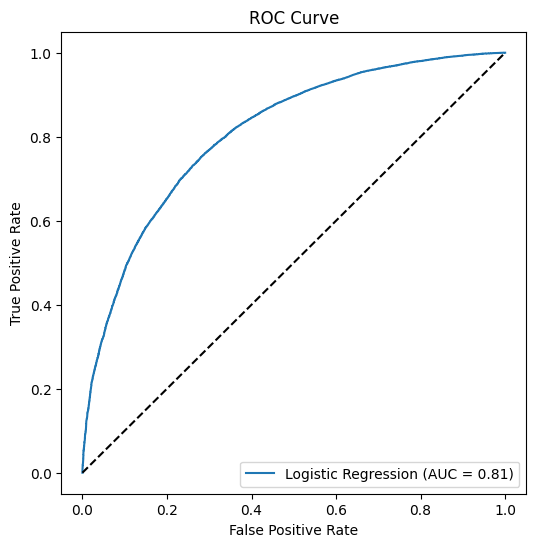

In [ ]:
#ROC (Receiver Operating Characteristic) Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_probs = log_reg.predict_proba(X_test)[:,1]

# Compute ROC curve values
# fpr = False Positive Rate (how many negatives are wrongly classified as positives)
# tpr = True Positive Rate (how many actual positives are correctly classified)
# thresholds = probability cutoff values corresponding to fpr/tpr points
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute Area Under the Curve (AUC), measures overall performance
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--') # Reference line (diagonal) represents random guessing (AUC = 0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

*   Cross Validation Logistic Regression with no class weights

In [ ]:
#Cross Validation
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation
cv_scores = cross_val_score(log_reg, X, y, cv=5, scoring='f1')

# Print F1 Score for each of the 5 folds
print("Cross Validation F1 Scores:", cv_scores)

# Print the mean F1 Score across all folds
print("Mean F1 Score:", cv_scores.mean())

Cross Validation F1 Scores: [0.86210186 0.8605765  0.85972949 0.86299134 0.86261376]
Mean F1 Score: 0.8616025919395698


2. Implementing LogisticRegression with class weights assigned

Logistic Regression with Class Weights Results
Accuracy: 0.7502774134974276

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.70      0.61     16595
           1       0.87      0.77      0.82     42883

    accuracy                           0.75     59478
   macro avg       0.70      0.73      0.71     59478
weighted avg       0.78      0.75      0.76     59478



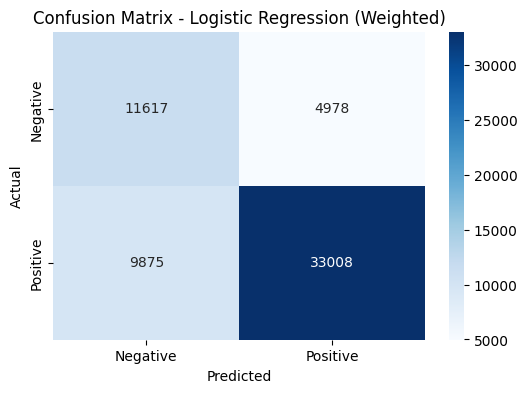

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Train Logistic Regression with class weights
log_reg_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42) #class_weight='balanced', automatically adjusts weights inversely proportional to class frequencies
log_reg_weighted.fit(X_train, y_train)

# 2. Predictions
y_pred_weighted = log_reg_weighted.predict(X_test)

# 3. Evaluation
print("Logistic Regression with Class Weights Results")
print("Accuracy:", accuracy_score(y_test, y_pred_weighted)) # Overall correctness of predictions
print("\nClassification Report:\n", classification_report(y_test, y_pred_weighted)) # Classification report showing Precision, Recall, F1-score for each class

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Logistic Regression (Weighted)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


*   ROC for Logistic Regression with class weights

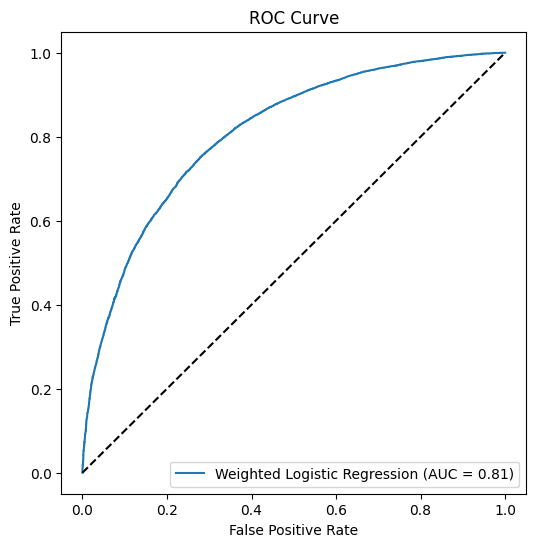

In [ ]:
#ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs_w = log_reg_weighted.predict_proba(X_test)[:,1]   # probability for positive class

fpr_w, tpr_w, _ = roc_curve(y_test, y_probs_w)
roc_auc_w = auc(fpr_w, tpr_w)

plt.figure(figsize=(6,6))
plt.plot(fpr_w, tpr_w, label=f"Weighted Logistic Regression (AUC = {roc_auc_w:.2f})")
plt.plot([0,1], [0,1], 'k--') # Reference line (diagonal) represents random guessing (AUC = 0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

*   Cross Validation for Logistic Regression with class weights

In [ ]:
#Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores_w = cross_val_score(log_reg_weighted, X, y, cv=5, scoring='f1')
print("Cross Validation F1 Scores (Weighted Logistic Regression):", cv_scores_w)
print("Mean F1 Score:", cv_scores_w.mean())

Cross Validation F1 Scores (Weighted Logistic Regression): [0.81776368 0.81468363 0.81270857 0.81853702 0.81668952]
Mean F1 Score: 0.8160764824100755


3. Implementing Random Forest

Random Forest Results
Accuracy: 0.8525337099431722

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.68      0.72     16595
           1       0.88      0.92      0.90     42883

    accuracy                           0.85     59478
   macro avg       0.82      0.80      0.81     59478
weighted avg       0.85      0.85      0.85     59478



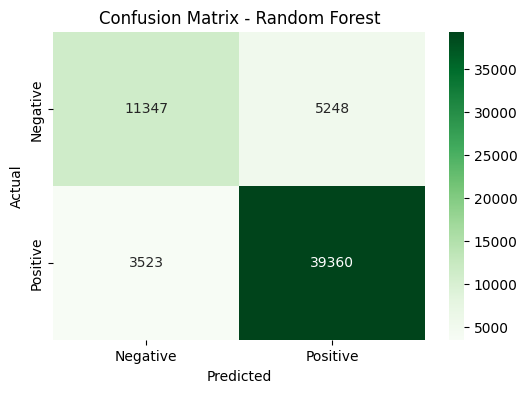

/tmp/ipykernel_6194/3029097611.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


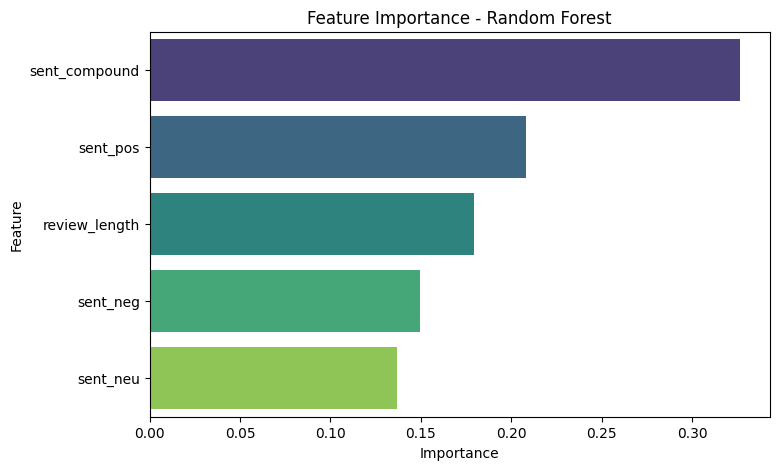

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # trees expand until all leaves are pure
    class_weight='balanced', # handle class imbalance automatically
    random_state=42,
    n_jobs=-1                # use all available CPU cores for faster training
)

rf_model.fit(X_train, y_train)

# 2. Predictions
y_pred_rf = rf_model.predict(X_test)

# 3. Evaluation
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf)) # overall % of correct predictions
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf)) # Classification report giving precision, recall, f1-score, and support for each class

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Feature Importance
importances = rf_model.feature_importances_ # how important each feature is in making predictions
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.show()

*   ROC for Random Forest Classifier

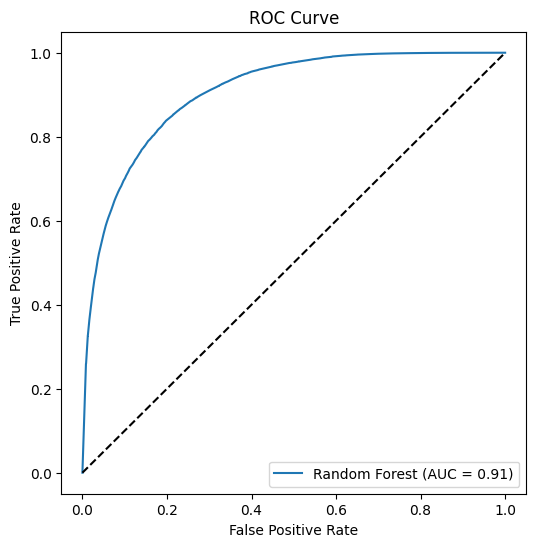

In [ ]:
#ROC
y_probs_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1], [0,1], 'k--') # Reference line (diagonal) represents random guessing (AUC = 0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

*   Cross Valdiation for Random Forest Classifier

In [ ]:
#Cross Validation
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print("Cross Validation F1 Scores (Random Forest):", cv_scores_rf)
print("Mean F1 Score:", cv_scores_rf.mean())

Cross Validation F1 Scores (Random Forest): [0.89819296 0.89903368 0.89742504 0.90576102 0.89798156]
Mean F1 Score: 0.8996788506526988


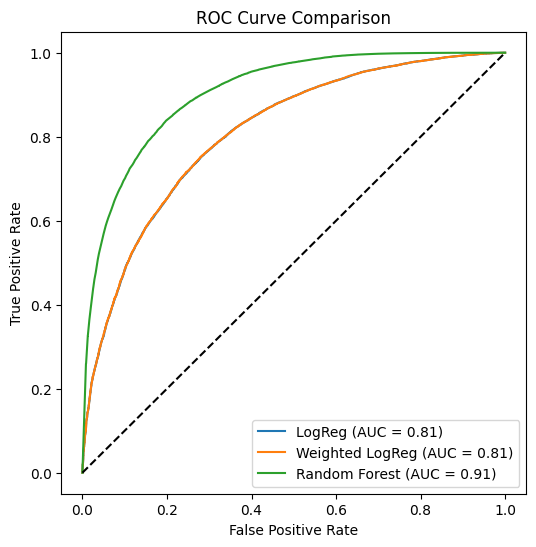

In [ ]:
plt.figure(figsize=(6,6))

# Normal Logistic Regression
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.2f})")
# Weighted Logistic Regression
plt.plot(fpr_w, tpr_w, label=f"Weighted LogReg (AUC = {roc_auc_w:.2f})")
# Random Forest
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")

plt.plot([0,1], [0,1], 'k--')  # Reference line (diagonal) represents random guessing (AUC = 0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

*   Appling GridSearchCV for Tuning Random Forest  HyperParameters

In [ ]:
#Grid Search CV for Tuning Hyper Parameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Base Random Forest model with class_weight fixed
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],        # number of trees
    'max_depth': [10, 20, None],      # depth of trees
    'min_samples_split': [2, 5],      # min samples to split a node
    'min_samples_leaf': [1, 2],       # min samples at leaf
    'max_features': ['sqrt']          # features considered at split, eg features are 16, sqrt(16) = 4, so 4 features at each split
}

# Grid Search setup
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           cv=3,             # 3-fold CV
                           scoring='f1',     # optimize for F1, showing harmonic mean of Precision and Recall
                           n_jobs=-1,
                           verbose=2) # show detailed progress of the search

# Fit on training data
grid_search.fit(X_train, y_train)

# Print results
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.8951911368063216


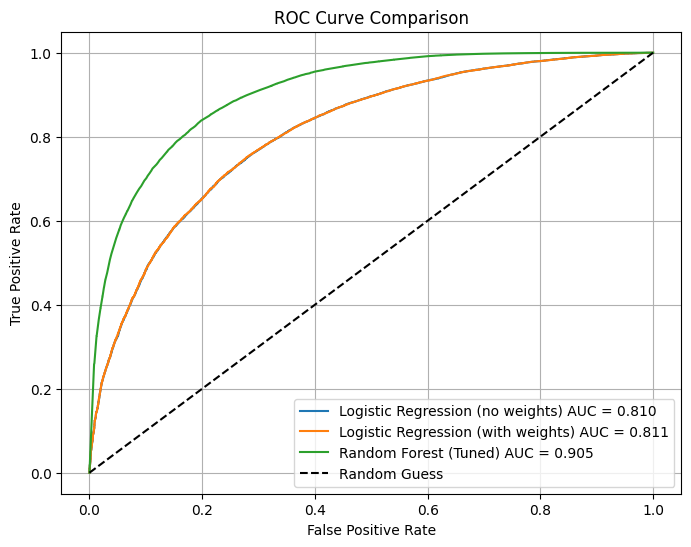

In [ ]:
#ROC Curve for Logistic Regression (no weights), Logistic Regression (with weights), and Random Forest

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# Getting predicted probabilities
# Logistic Regression (no weights)
y_pred_prob_log = log_reg.predict_proba(X_test)[:, 1]

# Logistic Regression (with weights)
y_pred_prob_log_w = log_reg_weighted.predict_proba(X_test)[:, 1]

# Random Forest (Tuned)
rf_model_tuned = grid_search.best_estimator_
y_pred_prob_rf_tuned = rf_model_tuned.predict_proba(X_test)[:, 1]


#Computing ROC curve values
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_log_w, tpr_log_w, _ = roc_curve(y_test, y_pred_prob_log_w)
roc_auc_log_w = auc(fpr_log_w, tpr_log_w)

fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_pred_prob_rf_tuned)
roc_auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)

#Plotting all three curves together
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (no weights) AUC = {roc_auc_log:.3f}")
plt.plot(fpr_log_w, tpr_log_w, label=f"Logistic Regression (with weights) AUC = {roc_auc_log_w:.3f}")
plt.plot(fpr_rf_tuned, tpr_rf_tuned, label=f"Random Forest (Tuned) AUC = {roc_auc_rf_tuned:.3f}")


#Reference line for random guessing
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#Advanced Model: Sales Classification using XGBoost

In [ ]:
!pip install -q xgboost joblib shap

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve, auc)
from xgboost import XGBClassifier

sns.set(style="whitegrid", palette="muted", font_scale=1.05)

In [ ]:
# Try to use df if in memory, otherwise find a saved CSV
try:
    df
    print("Using existing 'df' object from the notebook.")
except NameError:
    # Try a list of expected filenames
    filenames = ["reviews_with_features.csv", "reviews_with_sentiment.csv", "Balanced_Reviews.csv", "product_level_agg.csv"]
    loaded = False
    for fname in filenames:
        if os.path.exists(fname):
            df = pd.read_csv(fname)
            print(f"Loaded dataset from: {fname}")
            loaded = True
            break
    if not loaded:
        raise FileNotFoundError(
            "No in-memory 'df' and none of expected CSVs were found. Upload 'reviews_with_sentiment.csv' or run preprocessing cells."
        )

print("Dataset shape:", df.shape)
print("Preview columns:", df.columns.tolist()[:40])
df.head(2)

Using existing 'df' object from the notebook.
Dataset shape: (297389, 26)
Preview columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'date', 'review_length', 'help_ratio', 'year', 'clean_text', 'year_group', 'sent_pos', 'sent_neg', 'sent_neu', 'sent_compound', 'review_length_words', 'review_length_chars', 'sentiment_category', 'review_age_days', 'rating_binary', 'YearMonth']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,...,sent_pos,sent_neg,sent_neu,sent_compound,review_length_words,review_length_chars,sentiment_category,review_age_days,rating_binary,YearMonth
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,...,0.305,0.000,0.695,0.9441,48,259,Positive,4202,1,2011-04
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,...,0.155,0.091,0.754,0.8265,92,484,Positive,3220,1,2008-08


In [ ]:
# Basic sanity / ensure expected columns
expected_cols = ['ProductId','Text','clean_text','Score','sent_compound','sent_pos','sent_neg',
                 'sent_neu','review_length','review_length_words','help_ratio','rating_binary','Time','date']
present = {c: c in df.columns for c in expected_cols}
print("Column presence check (True means present):")
for k,v in present.items():
    print(f"  {k}: {v}")

# If 'Text' missing but 'clean_text' present, copy so aggregation works
if 'Text' not in df.columns and 'clean_text' in df.columns:
    df['Text'] = df['clean_text']

# Ensure ProductId exists
if 'ProductId' not in df.columns:
    raise KeyError("No 'ProductId' column found. Aggregation requires ProductId.")

Column presence check (True means present):
  ProductId: True
  Text: True
  clean_text: True
  Score: True
  sent_compound: True
  sent_pos: True
  sent_neg: True
  sent_neu: True
  review_length: True
  review_length_words: True
  help_ratio: True
  rating_binary: True
  Time: True
  date: True


In [ ]:
# Build aggregation map (means only for available columns)
agg_map_candidate = {
    'Score': 'mean',
    'sent_compound': 'mean',
    'sent_pos': 'mean',
    'sent_neg': 'mean',
    'sent_neu': 'mean',
    'review_length': 'mean',
    'review_length_words': 'mean',
    'rating_binary': 'mean'
}
# Keep only columns that exist in df
agg_map = {c: agg for c, agg in agg_map_candidate.items() if c in df.columns}

# Compute aggregated means
agg_means = df.groupby('ProductId').agg(agg_map).reset_index()

# Compute ReviewCount robustly (count of rows per ProductId)
review_counts = df.groupby('ProductId').size().rename('ReviewCount').reset_index()

# Merge means + counts
agg_df = pd.merge(agg_means, review_counts, on='ProductId', how='left')

# Add MaxReviewAgeDays if available
if 'review_age_days' in df.columns:
    max_age = df.groupby('ProductId')['review_age_days'].max().rename('MaxReviewAgeDays').reset_index()
    agg_df = pd.merge(agg_df, max_age, on='ProductId', how='left')

# Create PositiveRatio if rating_binary was aggregated
if 'rating_binary' in agg_df.columns:
    agg_df['PositiveRatio'] = agg_df['rating_binary']

print("Aggregated product-level shape:", agg_df.shape)
display(agg_df.head())


Aggregated product-level shape: (49293, 12)


,ProductId,Score,sent_compound,sent_pos,sent_neg,sent_neu,review_length,review_length_words,rating_binary,ReviewCount,MaxReviewAgeDays,PositiveRatio
0,0006641040,4.045455,0.676091,0.169864,0.024273,0.805864,88.00,86.409091,0.772727,22,4559,0.772727
1,141278509X,5.000000,0.927400,0.214000,0.030000,0.757000,66.00,64.000000,1.000000,1,4534,1.000000
2,2734888454,2.000000,0.793400,0.141000,0.055000,0.804000,65.00,65.000000,0.000000,1,2908,0.000000
3,7310172001,4.300000,0.643922,0.183100,0.043980,0.772920,78.78,76.760000,0.820000,50,4704,0.820000
4,7310172101,4.300000,0.643922,0.183100,0.043980,0.772920,78.78,76.760000,0.820000,50,4704,0.820000


In [ ]:
# Safety check for ReviewCount
if 'ReviewCount' not in agg_df.columns:
    raise RuntimeError("ReviewCount missing in agg_df — aggregation step failed.")

# Default threshold: median (change to quantile(0.75) for top-25%)
median_reviews = agg_df['ReviewCount'].median()
agg_df['SalesClass'] = (agg_df['ReviewCount'] > median_reviews).astype(int)

print(f"Using ReviewCount median = {median_reviews:.0f} to define SalesClass (1 = High).")
print("SalesClass distribution:")
print(agg_df['SalesClass'].value_counts())

display(agg_df[['ProductId','ReviewCount','SalesClass']].head())


Using ReviewCount median = 2 to define SalesClass (1 = High).
SalesClass distribution:
SalesClass
0    28117
1    21176
Name: count, dtype: int64


,ProductId,ReviewCount,SalesClass
0,0006641040,22,1
1,141278509X,1,0
2,2734888454,1,0
3,7310172001,50,1
4,7310172101,50,1


In [ ]:
# Candidate features (exclude ReviewCount)
candidate_features = [
    'Score', 'sent_compound', 'sent_pos', 'sent_neg', 'sent_neu',
    'review_length', 'review_length_words', 'PositiveRatio', 'MaxReviewAgeDays'
]

# Keep only those present in agg_df
features = [f for f in candidate_features if f in agg_df.columns]

# Build X and y (fill missing with 0)
X = agg_df[features].fillna(0).copy()
y = agg_df['SalesClass'].copy()

print("Selected features (ReviewCount excluded):", features)
print("X shape:", X.shape, "y shape:", y.shape)
display(X.describe().T)


Selected features (ReviewCount excluded): ['Score', 'sent_compound', 'sent_pos', 'sent_neg', 'sent_neu', 'review_length', 'review_length_words', 'PositiveRatio', 'MaxReviewAgeDays']
X shape: (49293, 9) y shape: (49293,)


,count,mean,std,min,25%,50%,75%,max
Score,49293.0,3.994925,1.174463,1.0000,3.444444,4.333333,5.000000,5.0000
sent_compound,49293.0,0.587519,0.389854,-0.9972,0.440400,0.697089,0.873200,0.9999
sent_pos,49293.0,0.177917,0.081770,0.0000,0.128000,0.173375,0.220167,0.7890
sent_neg,49293.0,0.045728,0.042347,0.0000,0.016000,0.039615,0.063500,0.7180
sent_neu,49293.0,0.776341,0.077543,0.2110,0.735789,0.779000,0.821500,1.0000
review_length,49293.0,83.273632,66.469166,7.0000,45.714286,69.000000,99.666667,2520.0000
review_length_words,49293.0,80.604970,63.336371,2.0000,44.500000,67.000000,96.500000,2350.0000
PositiveRatio,49293.0,0.726766,0.351941,0.0000,0.500000,0.913043,1.000000,1.0000
MaxReviewAgeDays,49293.0,4197.292800,524.802488,248.0000,4000.000000,4381.000000,4565.000000,4750.0000


In [ ]:
# Stratified split to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test class distribution:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (39434, 9) Test shape: (9859, 9)
Train class distribution:
 SalesClass
0    0.57
1    0.43
Name: proportion, dtype: float64
Test class distribution:
 SalesClass
0    0.57
1    0.43
Name: proportion, dtype: float64


In [ ]:
# Train XGBoost classifier (trees do not require scaling)
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:42:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

Classification Report:
              precision    recall  f1-score   support

           0     0.9319    0.9716    0.9513      5624
           1     0.9600    0.9058    0.9321      4235

    accuracy                         0.9433      9859
   macro avg     0.9460    0.9387    0.9417      9859
weighted avg     0.9440    0.9433    0.9431      9859

Accuracy: 0.9433 | Precision: 0.9600 | Recall: 0.9058 | F1: 0.9321 | ROC-AUC: 0.9864


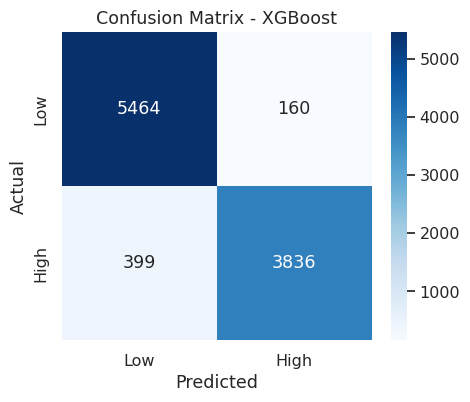

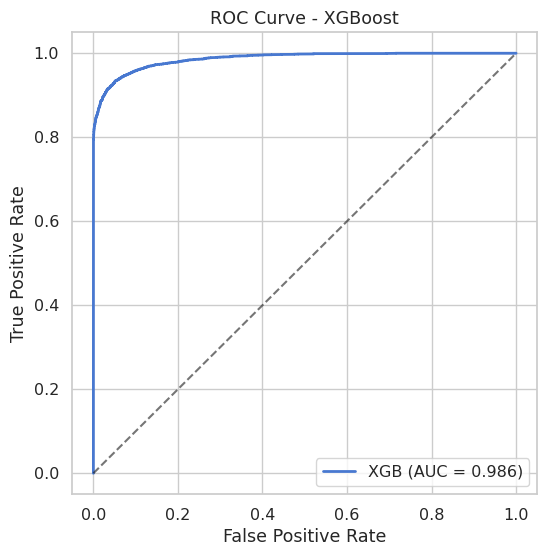

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:42:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:42:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:42:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:42:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

5-fold CV F1 scores: [0.9255 0.9303 0.9299 0.9288 0.9303]
Mean CV F1: 0.929


In [ ]:
# Predictions & probabilities
y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")

# Confusion matrix plot (inline)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()


print("\n")

# ROC Curve (inline)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGB (AUC = {roc_auc_val:.3f})", linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()

# Cross-validated F1 (StratifiedKFold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(xgb_clf, X, y, cv=skf, scoring='f1')
print("5-fold CV F1 scores:", np.round(cv_f1,4))
print("Mean CV F1:", np.round(cv_f1.mean(),4))


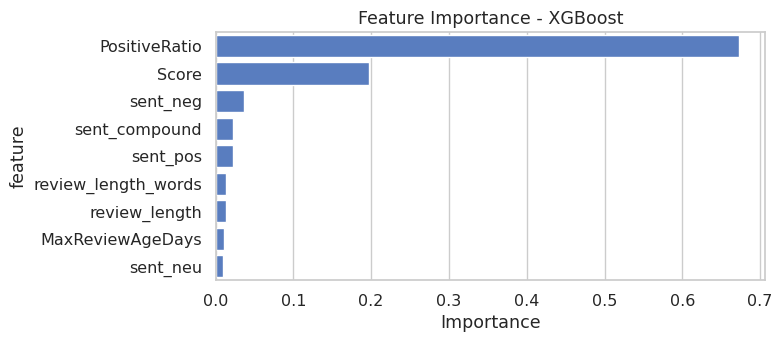

,feature,importance
7,PositiveRatio,0.673036
0,Score,0.196981
3,sent_neg,0.036422
1,sent_compound,0.022784
2,sent_pos,0.022753
6,review_length_words,0.013984
5,review_length,0.013358
8,MaxReviewAgeDays,0.010723
4,sent_neu,0.009957


In [ ]:
# Feature importance from XGBoost
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': xgb_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, max(3, len(features)*0.4)))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(feat_imp)

In [ ]:
# Save the trained model and aggregated product-level dataset
model_path = "sales_classifier_xgb.pkl"
joblib.dump(xgb_clf, model_path)
print("Saved model to:", model_path)

agg_path = "product_level_agg.csv"
agg_df.to_csv(agg_path, index=False)
print("Saved aggregated product-level data to:", agg_path)

Saved model to: sales_classifier_xgb.pkl
Saved aggregated product-level data to: product_level_agg.csv


In [ ]:
df.head(2)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,...,sent_pos,sent_neg,sent_neu,sent_compound,review_length_words,review_length_chars,sentiment_category,review_age_days,rating_binary,YearMonth
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,...,0.305,0.000,0.695,0.9441,48,259,Positive,4202,1,2011-04
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,...,0.155,0.091,0.754,0.8265,92,484,Positive,3220,1,2008-08




> RandomSearchCV for XGBoost tuning



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': np.arange(100, 600, 50),
    'max_depth': np.arange(3, 12, 1),
    'learning_rate': np.linspace(0.01, 0.3, 20),
    'subsample': np.linspace(0.6, 1.0, 10),
    'colsample_bytree': np.linspace(0.5, 1.0, 10),
    'gamma': np.linspace(0, 5, 10),
    'min_child_weight': np.arange(1, 10, 1)
}

In [ ]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,                 # number of random combinations to try
    scoring='f1',              # optimizing F1-score
    cv=5,                      # 5-fold stratified CV
    verbose=2,
    random_state=42,
    n_jobs=-1                  # use all cores
)

In [ ]:
print("Starting RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print("\nRandom Search Completed!")
print("Best Parameters Found:")
print(random_search.best_params_)

print("\nBest F1 Score (CV):", random_search.best_score_)

Starting RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:47:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Search Completed!
Best Parameters Found:
{'subsample': np.float64(0.8222222222222222), 'n_estimators': np.int64(350), 'min_child_weight': np.int64(2), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.20842105263157895), 'gamma': np.float64(0.5555555555555556), 'colsample_bytree': np.float64(0.9444444444444444)}

Best F1 Score (CV): 0.932532213080458


In [ ]:
# Retrieve the best model
best_xgb = random_search.best_estimator_

print("Retraining model with best parameters...")
best_xgb.fit(X_train, y_train)

print("Retraining completed.")

Retraining model with best parameters...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:47:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Retraining completed.


In [ ]:
# Predictions
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# Classification report
print("=== Tuned Model Classification Report ===")
print(classification_report(y_test, y_pred_tuned, digits=4))

# Metrics
acc = accuracy_score(y_test, y_pred_tuned)
prec = precision_score(y_test, y_pred_tuned)
rec = recall_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)
auc_val = roc_auc_score(y_test, y_prob_tuned)

print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc_val:.4f}")

=== Tuned Model Classification Report ===
              precision    recall  f1-score   support

           0     0.9386    0.9650    0.9516      5624
           1     0.9517    0.9162    0.9336      4235

    accuracy                         0.9440      9859
   macro avg     0.9451    0.9406    0.9426      9859
weighted avg     0.9442    0.9440    0.9439      9859

Accuracy: 0.9440 | Precision: 0.9517 | Recall: 0.9162 | F1: 0.9336 | AUC: 0.9865


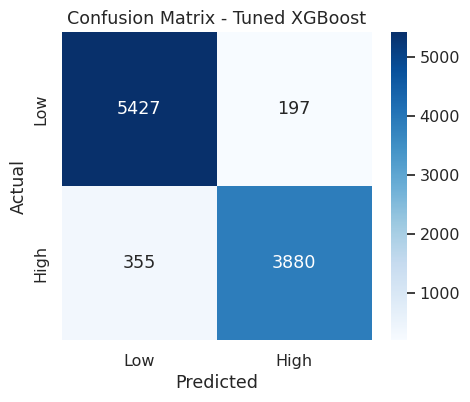

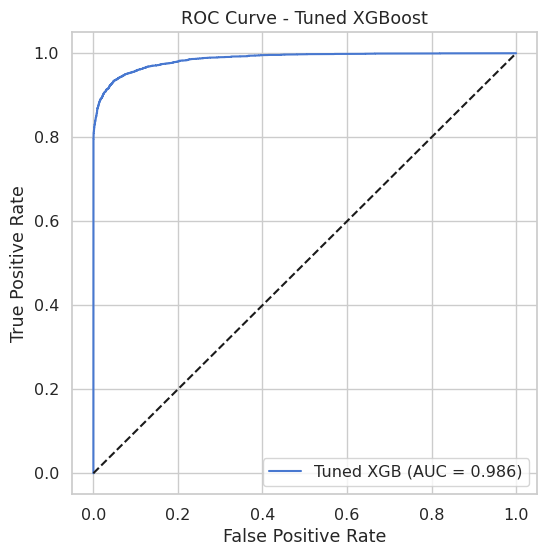

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\n")
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Tuned XGB (AUC = {auc_val:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.grid(True)
plt.show()


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1_scores = cross_val_score(best_xgb, X, y, scoring='f1', cv=skf, n_jobs=-1)

print("Cross-validated F1 Scores:", np.round(cv_f1_scores, 4))
print("Mean CV F1:", np.round(cv_f1_scores.mean(), 4))

Cross-validated F1 Scores: [0.928  0.934  0.9331 0.9325 0.9354]
Mean CV F1: 0.9326


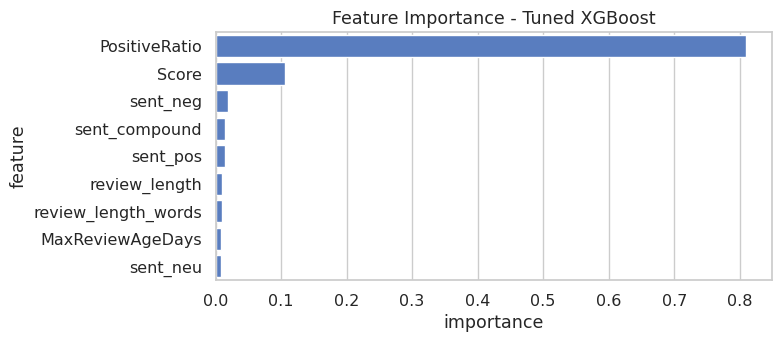

,feature,importance
7,PositiveRatio,0.809020
0,Score,0.106067
3,sent_neg,0.019066
1,sent_compound,0.014947
2,sent_pos,0.014019
5,review_length,0.010399
6,review_length_words,0.010062
8,MaxReviewAgeDays,0.008394
4,sent_neu,0.008026


In [ ]:
feat_imp_tuned = pd.DataFrame({
    'feature': features,
    'importance': best_xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, max(3, len(features)*0.4)))
sns.barplot(data=feat_imp_tuned, x='importance', y='feature')
plt.title("Feature Importance - Tuned XGBoost")
plt.tight_layout()
plt.show()

display(feat_imp_tuned)

In [ ]:
import joblib

# Save trained sales classification model
joblib.dump(best_xgb, "sales_classifier.pkl")

# Save feature order used during training
joblib.dump(features, "feature_order.pkl")

print("Saved sales_classifier.pkl and feature_order.pkl")

Saved sales_classifier.pkl and feature_order.pkl


# SHAP(A)

In [ ]:
# Install shap if not present (Colab)
!pip install -q shap

# Imports
import os
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
# Try common model variable names or files
model = None
for varname in ['best_xgb','best_model','xgb_clf','xgb_sales_classifier_tuned']:
    if varname in globals():
        model = globals()[varname]
        print("Using model from variable:", varname)
        break

if model is None:
    # try common filenames
    for fname in ["xgb_sales_classifier_tuned.pkl", "sales_classifier_xgb_noreviewcount.pkl", "xgb_best.pkl"]:
        if os.path.exists(fname):
            model = joblib.load(fname)
            print("Loaded model from file:", fname)
            break

if model is None:
    raise RuntimeError("Tuned model not found. Make sure variable (best_xgb/xgb_clf) exists or file 'xgb_sales_classifier_tuned.pkl' is present.")

# Load aggregated dataset (agg_df) from memory or CSV
if 'agg_df' in globals():
    agg_df = globals()['agg_df']
    print("Using agg_df from memory.")
elif os.path.exists("product_level_agg.csv"):
    agg_df = pd.read_csv("product_level_agg.csv")
    print("Loaded agg_df from product_level_agg.csv")
else:
    raise RuntimeError("Aggregated product-level dataframe 'agg_df' not found. Ensure agg_df exists or product_level_agg.csv is present.")

# Determine features used in training. If you saved 'features' earlier, use it.
if 'features' in globals():
    features = globals()['features']
    print("Using features from variable 'features'.")
else:
    # Try a reasonable default order — adjust if your feature names differ
    candidate = ['PositiveRatio','help_ratio','Score','sent_neg','sent_compound','sent_pos',
                 'review_length_words','review_length','MaxReviewAgeDays','sent_neu']
    features = [f for f in candidate if f in agg_df.columns]
    print("Inferred features:", features)

if len(features) == 0:
    raise RuntimeError("No features identified. Set the 'features' list to the columns used for training.")

# Build X (feature matrix) and optional y
X = agg_df[features].fillna(0).copy()
y = agg_df['SalesClass'] if 'SalesClass' in agg_df.columns else None

print("Prepared X with shape:", X.shape, "y present:", y is not None)


Using model from variable: best_xgb
Using agg_df from memory.
Using features from variable 'features'.
Prepared X with shape: (49293, 9) y present: True


In [ ]:
# Subsample X for SHAP computation (SHAP can be slow on very large datasets)
RANDOM_STATE = 42
max_samples = 3000   # change lower if memory/time is a problem
if X.shape[0] > max_samples:
    X_shap = X.sample(n=max_samples, random_state=RANDOM_STATE)
else:
    X_shap = X.copy()

print("X_shap shape used for SHAP computation:", X_shap.shape)


X_shap shape used for SHAP computation: (3000, 9)


In [ ]:
# Robust SHAP computation: try shap.Explainer, fallback to TreeExplainer on booster/model
shap_values = None
explainer = None

print("shap version:", shap.__version__)
try:
    import xgboost as xgb
    print("xgboost version:", xgb.__version__)
except Exception:
    pass

# Attempt 1: unified API
try:
    print("Attempting shap.Explainer(model, X_shap)...")
    explainer = shap.Explainer(model, X_shap)   # unified API works for many wrappers
    out = explainer(X_shap)
    shap_values = out.values if hasattr(out, "values") else np.asarray(out)
    print("Success with shap.Explainer ; shap_values shape:", getattr(shap_values, "shape", None))
except Exception as e1:
    print("shap.Explainer failed:", str(e1))

# Attempt 2: TreeExplainer on booster or model
if shap_values is None:
    try:
        print("Attempting shap.TreeExplainer on model.get_booster() or model...")
        # prefer native booster if available
        booster = None
        if hasattr(model, "get_booster"):
            booster = model.get_booster()
            explainer = shap.TreeExplainer(booster)
            print("Using model.get_booster() with TreeExplainer")
        else:
            explainer = shap.TreeExplainer(model)
            print("Using TreeExplainer(model)")
        shap_values = explainer.shap_values(X_shap)
        print("Success with TreeExplainer ; shap_values type:", type(shap_values))
    except Exception as e2:
        print("TreeExplainer attempt failed:", str(e2))
        # final fallback: try computing SHAP for single row to reveal the underlying error
        try:
            print("Attempting TreeExplainer on single sample to debug...")
            expl = shap.TreeExplainer(model)
            tmp = expl.shap_values(X_shap.iloc[[0]])
            shap_values = expl.shap_values(X_shap)
            print("Succeeded on retry")
        except Exception as e3:
            raise RuntimeError("All SHAP explainer attempts failed. Last error: " + str(e3))

# Normalize shap_values to an ndarray of class-1 contributions if needed
if isinstance(shap_values, list):
    # common format: [class0_shap_array, class1_shap_array]
    if len(shap_values) >= 2:
        shap_vals = shap_values[1]
        print("Selected class-1 SHAP values from list.")
    else:
        shap_vals = np.asarray(shap_values[0])
        print("Converted single-entry list to array.")
else:
    shap_vals = np.asarray(shap_values)

print("Final shap_vals shape:", getattr(shap_vals, "shape", None))
if shap_vals.shape[0] != X_shap.shape[0]:
    print("Warning: number of SHAP rows", shap_vals.shape[0], "!= X_shap rows", X_shap.shape[0])


shap version: 0.51.0
xgboost version: 3.2.0
Attempting shap.Explainer(model, X_shap)...


100%|===================| 2997/3000 [01:26<00:00]       

Success with shap.Explainer ; shap_values shape: (3000, 9)
Final shap_vals shape: (3000, 9)


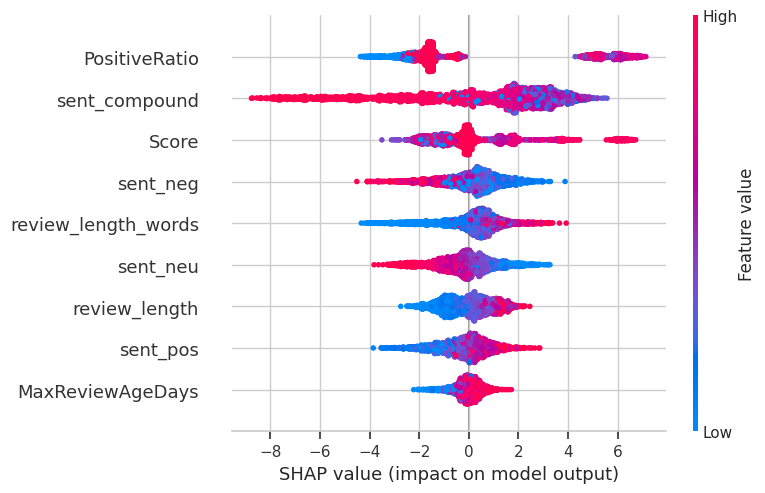

Saved SHAP summary (beeswarm) to: shap_summary_beeswarm.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Safety checks
if 'shap_vals' not in globals():
    raise RuntimeError("shap_vals not found. Ensure Cell 5 ran successfully.")
if 'X_shap' not in globals():
    raise RuntimeError("X_shap not found. Ensure Cell 4 ran successfully.")

# Create beeswarm summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_shap, plot_type="dot", show=True)

# Save for Blackbook / PPT
out_file = "shap_summary_beeswarm.png"
plt.savefig(out_file, bbox_inches='tight', dpi=200)
print("Saved SHAP summary (beeswarm) to:", out_file)


SHAP Bar Plot(Global Importance)

/tmp/ipykernel_6194/1544972987.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


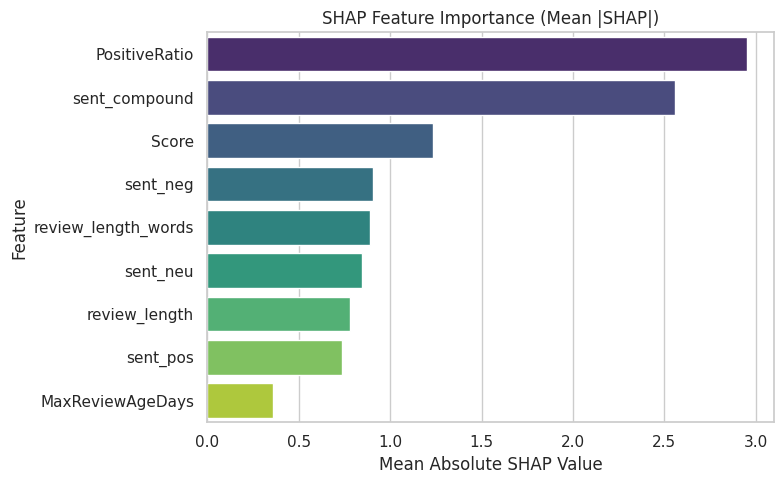

,Feature,MeanAbsSHAP
7,PositiveRatio,2.951982
1,sent_compound,2.560110
0,Score,1.234030
3,sent_neg,0.905514
6,review_length_words,0.892031
4,sent_neu,0.844471
5,review_length,0.781860
2,sent_pos,0.736963
8,MaxReviewAgeDays,0.361465


In [ ]:
# Compute mean absolute SHAP values
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': X_shap.columns,
    'MeanAbsSHAP': mean_abs_shap
}).sort_values(by='MeanAbsSHAP', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=shap_importance_df,
    x='MeanAbsSHAP',
    y='Feature',
    palette='viridis'
)

plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.tight_layout()

plt.savefig("shap_bar_importance.png", dpi=200)
plt.show()

shap_importance_df

SHAP Dependence Plot (Top 2 Features)

Top features for dependence plots: ['PositiveRatio', 'sent_compound']


<Figure size 600x400 with 0 Axes>

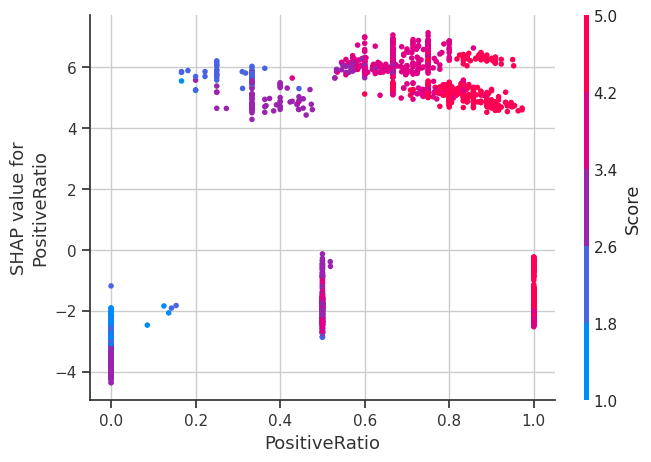

<Figure size 640x480 with 0 Axes>

<Figure size 600x400 with 0 Axes>

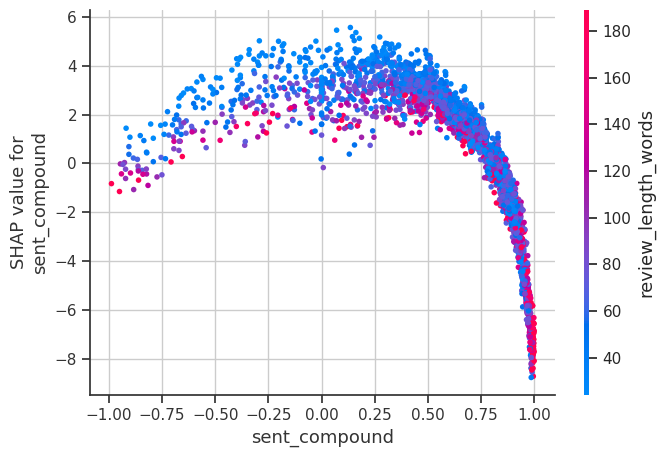

<Figure size 640x480 with 0 Axes>

In [ ]:
# Select top 2 important features
top_features = shap_importance_df['Feature'].head(2).tolist()
print("Top features for dependence plots:", top_features)

for feature in top_features:
    plt.figure(figsize=(6, 4))
    shap.dependence_plot(
        feature,
        shap_vals,
        X_shap,
        show=True
    )
    plt.savefig(f"shap_dependence_{feature}.png", dpi=200)


SHAP Waterfall Plot (Single Product)

Explaining product at index: 1843
Predicted probability (High Sales): 0.99999917


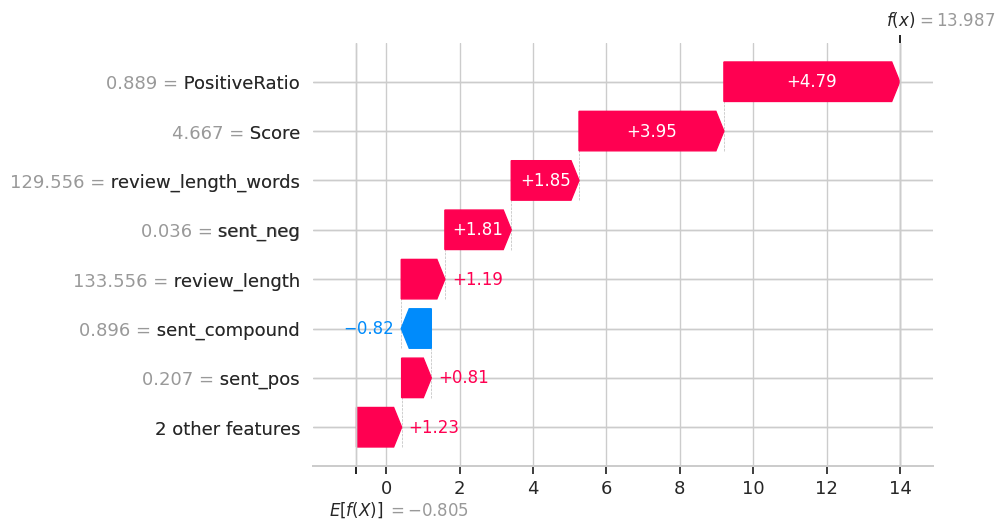

In [ ]:
# Choose one product (highest probability of High Sales)
probs = model.predict_proba(X_shap)[:, 1]
example_idx = np.argmax(probs)

print("Explaining product at index:", example_idx)
print("Predicted probability (High Sales):", probs[example_idx])

# Create SHAP Explanation object
shap_exp = shap.Explanation(
    values=shap_vals[example_idx],
    base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else explainer.expected_value[1],
    data=X_shap.iloc[example_idx],
    feature_names=X_shap.columns
)

# Plot waterfall
plt.figure(figsize=(7, 5))
shap.plots.waterfall(shap_exp, max_display=8)
plt.show()


# SALES SCORE / SALES METRIC PREDICTION (REGRESSION)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
# Safety check
if 'ReviewCount' not in agg_df.columns:
    raise ValueError("ReviewCount not found in agg_df")

# Create SalesScore using log transformation
agg_df['SalesScore'] = np.log1p(agg_df['ReviewCount'])

# Quick check
agg_df[['ReviewCount', 'SalesScore']].describe()

,ReviewCount,SalesScore
count,49293.000000,49293.000000
mean,6.033088,1.374434
std,15.851598,0.844386
min,1.000000,0.693147
25%,1.000000,0.693147
50%,2.000000,1.098612
75%,5.000000,1.791759
max,450.000000,6.111467


In [ ]:
# Features used (same as Phase 4A, excluding ReviewCount)
features = [
    'PositiveRatio',
    'help_ratio',
    'Score',
    'sent_compound',
    'sent_pos',
    'sent_neg',
    'review_length_words',
    'review_length',
    'MaxReviewAgeDays'
]

# Keep only available features
features = [f for f in features if f in agg_df.columns]

X = agg_df[features].fillna(0)
y = agg_df['SalesScore']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features used:", features)

X shape: (49293, 8)
y shape: (49293,)
Features used: ['PositiveRatio', 'Score', 'sent_compound', 'sent_pos', 'sent_neg', 'review_length_words', 'review_length', 'MaxReviewAgeDays']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (39434, 8)
Test size: (9859, 8)


In [ ]:
xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_reg.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


MAE  : 0.1875
RMSE : 0.2967
R²   : 0.8748


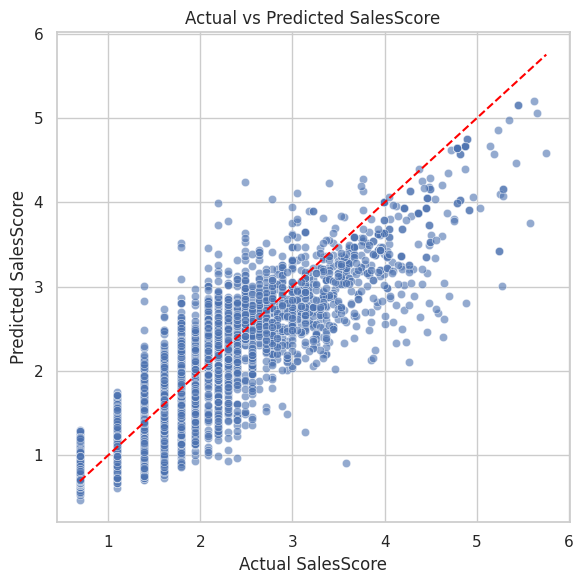

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual SalesScore")
plt.ylabel("Predicted SalesScore")
plt.title("Actual vs Predicted SalesScore")

plt.tight_layout()
plt.show()

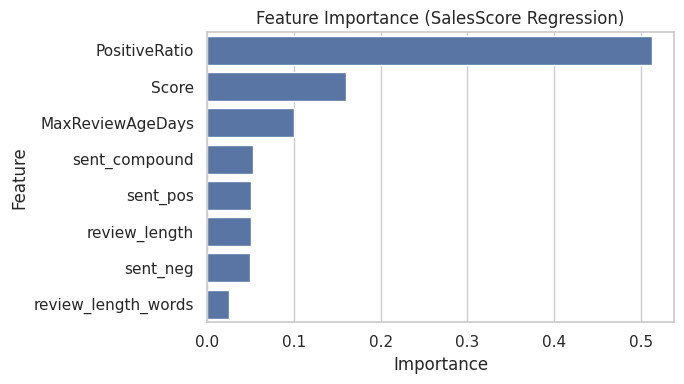

,Feature,Importance
0,PositiveRatio,0.512619
1,Score,0.159893
7,MaxReviewAgeDays,0.099734
2,sent_compound,0.052314
3,sent_pos,0.050671
6,review_length,0.050219
4,sent_neg,0.048985
5,review_length_words,0.025565


In [ ]:
importances = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=importances,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance (SalesScore Regression)")
plt.tight_layout()
plt.show()

importances

In [ ]:
min_score = agg_df["SalesScore"].min()
max_score = agg_df["SalesScore"].max()

print(min_score, max_score)

0.6931471805599453 6.111467339502679


In [ ]:
import joblib

# Save XGBoost regression model for SalesScore prediction
joblib.dump(xgb_reg, "sales_regressor.pkl")

# Save feature order for regression
joblib.dump(features, "reg_feature_order.pkl")

print("Saved sales_regressor.pkl and reg_feature_order.pkl")


joblib.dump(min_score, "sales_score_min.pkl")
joblib.dump(max_score, "sales_score_max.pkl")

print("Saved sales_score_min.pkl and sales_score_max.pkl")

Saved sales_regressor.pkl and reg_feature_order.pkl
Saved sales_score_min.pkl and sales_score_max.pkl


# SHAP(B)

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Create SHAP explainer for XGBoost Regressor
explainer_reg = shap.Explainer(xgb_reg, X_train)

# Compute SHAP values for test set
shap_values_reg = explainer_reg(X_test)

print("SHAP values shape:", shap_values_reg.values.shape)


100%|===================| 9853/9859 [03:56<00:00]       

SHAP values shape: (9859, 8)


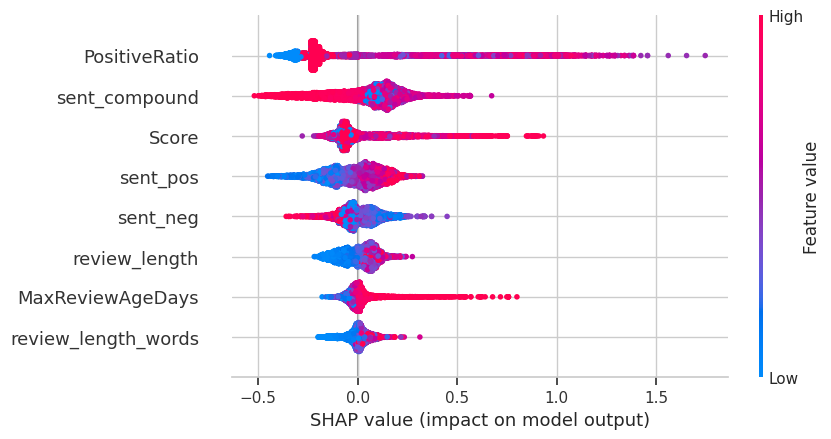

In [ ]:
# SHAP Summary Plot (Regression)

plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_values_reg, max_display=10)
plt.show()

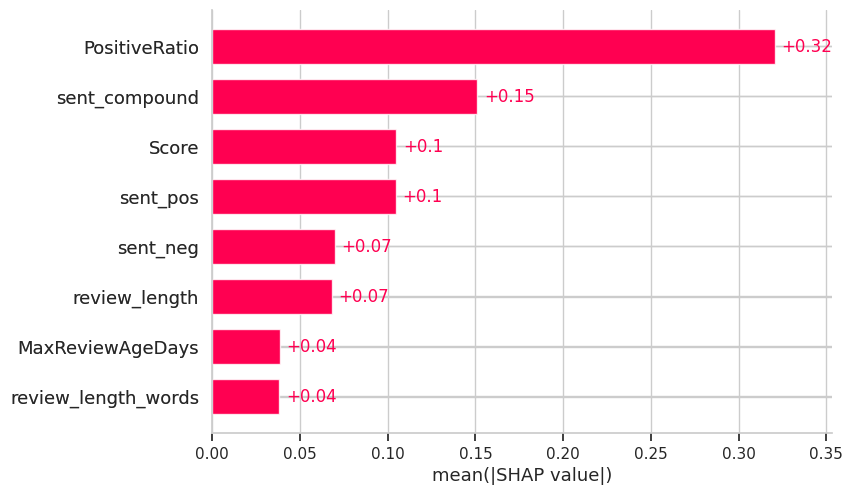

In [ ]:
# SHAP Bar Plot (Regression)

plt.figure(figsize=(7, 4))
shap.plots.bar(shap_values_reg, max_display=10)
plt.show()


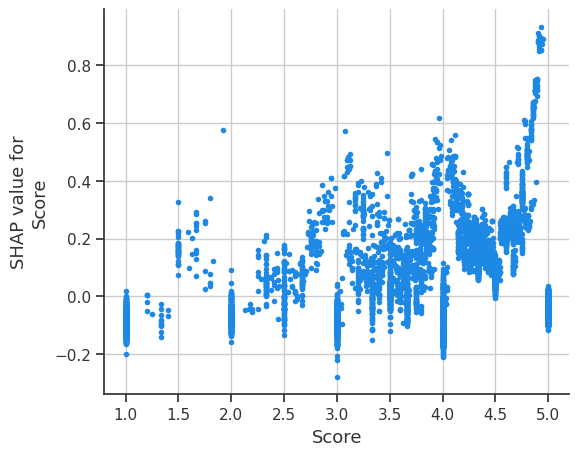

In [ ]:
# SHAP Dependence Plot
import shap

feature_name = "Score"   # change to PositiveRatio, sent_compound, etc.

# Extract raw SHAP values (numpy array)
shap_vals_array = shap_values_reg.values

shap.dependence_plot(
    feature_name,
    shap_vals_array,
    X_test,
    interaction_index=None
)


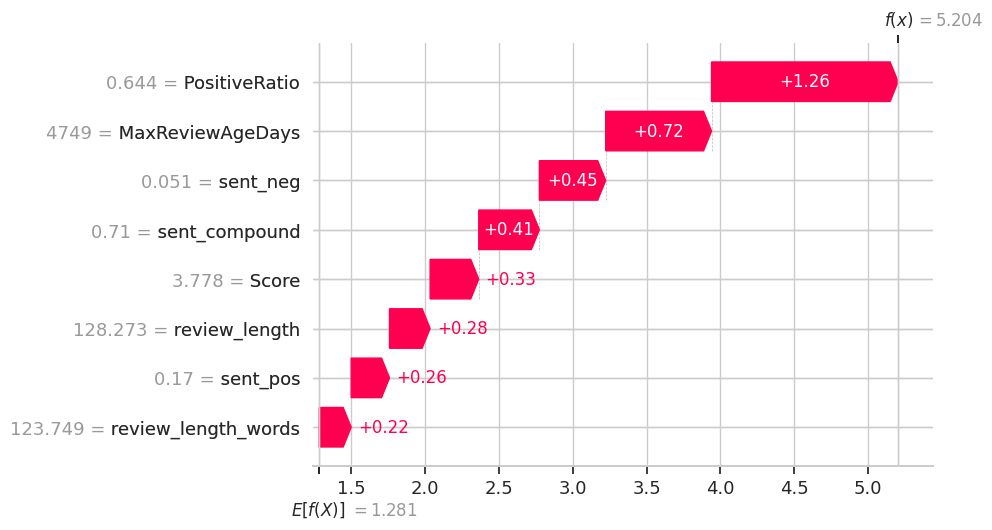

In [ ]:
# SHAP Waterfall Plot (High Sales)

# Pick product with highest predicted SalesScore
high_idx = np.argmax(y_pred)

shap.plots.waterfall(shap_values_reg[high_idx], max_display=8)
plt.show()


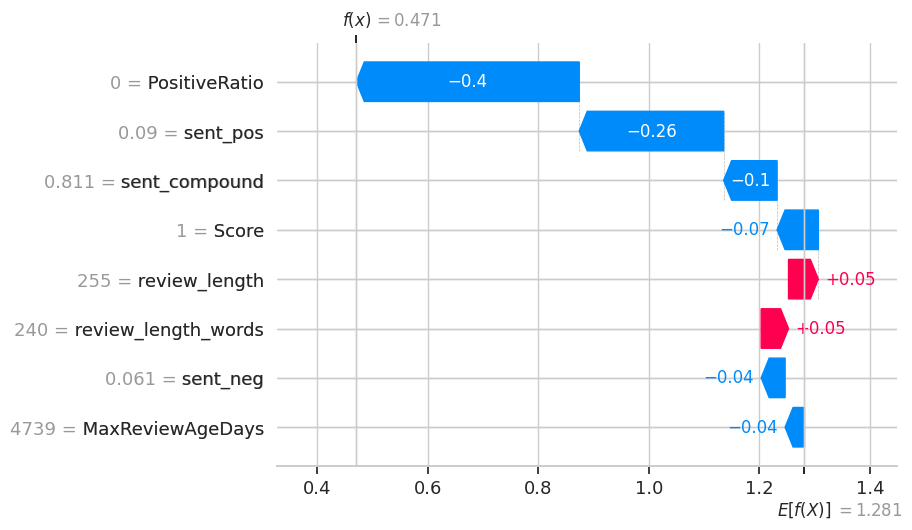

In [ ]:
# SHAP Waterfall Plot (Low Sales)
# Pick product with lowest predicted SalesScore
low_idx = np.argmin(y_pred)

shap.plots.waterfall(shap_values_reg[low_idx], max_display=8)
plt.show()


# Model Downloading for Deployment

In [ ]:
'''from google.colab import files

files.download("sales_classifier.pkl")
files.download("feature_order.pkl")
files.download("sales_regressor.pkl")
files.download("reg_feature_order.pkl")'''

'from google.colab import files\n\nfiles.download("sales_classifier.pkl")\nfiles.download("feature_order.pkl")\nfiles.download("sales_regressor.pkl")\nfiles.download("reg_feature_order.pkl")'

# Filtering product for testing

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Reviews.csv")

# Filter one real product
product_id = "B007JFMH8M"   # recommended
product_df = df[df["ProductId"] == product_id]

# Rename columns to match Streamlit app
product_df = product_df.rename(columns={
    "Text": "review_text",
    "Score": "rating",
    "HelpfulnessNumerator": "helpful_yes",
    "HelpfulnessDenominator": "helpful_total"
})

# Keep only required columns
product_df = product_df[[
    "review_text", "rating", "helpful_yes", "helpful_total"
]]

# Save CSV
product_df.to_csv("real_product_B007JFMH8M.csv", index=False)

print("Saved real-world test file with", len(product_df), "reviews")


Saved real-world test file with 0 reviews


In [ ]:
import pandas as pd

# Load full dataset
df = pd.read_csv("Reviews.csv")

# Choose a product
PRODUCT_ID = "B007JFMH8M"

# Filter reviews for one product
product_df = df[df["ProductId"] == PRODUCT_ID].copy()

# Keep only relevant columns for your app
product_df = product_df[
    ["Text", "Score", "HelpfulnessNumerator", "HelpfulnessDenominator", "Time"]
]

# Rename columns to match your app
product_df = product_df.rename(columns={
    "Text": "review_text",
    "Score": "rating",
    "HelpfulnessNumerator": "helpful_yes",
    "HelpfulnessDenominator": "helpful_total"
})

# Save sample CSV
output_file = f"real_product_{PRODUCT_ID}.csv"
product_df.to_csv(output_file, index=False)

print(f"Saved {output_file} with {len(product_df)} reviews")


Saved real_product_B007JFMH8M.csv with 0 reviews


# Extras

In [ ]:
low = agg_df["SalesScore"].quantile(0.05)
high = agg_df["SalesScore"].quantile(0.95)

print("P05:", low)
print("P95:", high)

import joblib
joblib.dump(low, "sales_score_p05.pkl")
joblib.dump(high, "sales_score_p95.pkl")

P05: 0.6931471805599453
P95: 3.1354942159291497


['sales_score_p95.pkl']